# LIMPIEZA DEL DATA SET

##  Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats #para la parte estadistica

In [3]:
data__train = pd.read_csv('../data/raw/train.csv')

### Dimensiones del Dataset

In [ ]:
# Mostrar las dimensiones del dataset (filas, columnas)
print(f"Dimensiones del dataset: {data__train.shape[0]} filas, {data__train.shape[1]} columnas")

Dimensiones del dataset: 9800 filas, 18 columnas


In [ ]:
data__train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

# NULOS

In [ ]:
data__train.isnull().sum()
# 11 DATOS FALTANTES EN POSTAL CODE

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# Mostrar el porcentaje de valores nulos por columna
print("Porcentaje de valores nulos por columna:")
display(data__train.isnull().mean() * 100)

Porcentaje de valores nulos por columna:


,0
Row ID,0.000000
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Ship Mode,0.000000
Customer ID,0.000000
Customer Name,0.000000
Segment,0.000000
Country,0.000000
City,0.000000


### Conversión de Variables de Fecha a Formato `datetime`


In [ ]:
# CORREGIR LAS FECHAS
data__train['Order Date'] = pd.to_datetime(data__train['Order Date'], dayfirst=True, format='mixed')
data__train['Ship Date'] = pd.to_datetime(data__train['Ship Date'], dayfirst=True, format='mixed')

##  Limpieza de Datos


In [51]:
data__train['Postal Code'] = data__train['Postal Code'].astype("Int64").astype(str)

ValueError: invalid literal for int() with base 10: 'Desconocido'

### Verificación de Nulos Después del Tratamiento

Se comprueba nuevamente el conteo de valores nulos para confirmar que la columna `Postal Code` ya no contiene entradas faltantes. Esto asegura la integridad del dataset antes de proceder con el análisis.

In [ ]:
data__train["Postal Code"].unique() #esta variable no es relevante para el analisis del caso, pero se debe tratar para su debida visualizacion

array(['42420', '90036', '33311', '90032', '28027', '98103', '76106',
       '53711', '84084', '94109', '68025', '19140', '84057', '90049',
       '77095', '75080', '77041', '60540', '32935', '55122', '48185',
       '19901', '47150', '10024', '12180', '90004', '60610', '85234',
       '22153', '10009', '49201', '38109', '77070', '35601', '94122',
       '27707', '60623', '29203', '55901', '55407', '97206', '55106',
       '80013', '28205', '60462', '10035', '50322', '43229', '37620',
       '19805', '61701', '85023', '95661', '64055', '91104', '43055',
       '53132', '85254', '95123', '98105', '98115', '73034', '90045',
       '19134', '88220', '78207', '77036', '62521', '71203', '6824',
       '75051', '92374', '45011', '7090', '19120', '44312', '80219',
       '75220', '37064', '90604', '48601', '44256', '43017', '48227',
       '38401', '33614', '95051', '55044', '92037', '77506', '94513',
       '27514', '7960', '45231', '94110', '90301', '33319', '80906',
       '7109', '48180',

In [ ]:
data__train["Postal Code"] = data__train["Postal Code"].replace(["nan", "<NA>"], "Desconocido")
data__train["Postal Code"].unique()

array(['42420', '90036', '33311', '90032', '28027', '98103', '76106',
       '53711', '84084', '94109', '68025', '19140', '84057', '90049',
       '77095', '75080', '77041', '60540', '32935', '55122', '48185',
       '19901', '47150', '10024', '12180', '90004', '60610', '85234',
       '22153', '10009', '49201', '38109', '77070', '35601', '94122',
       '27707', '60623', '29203', '55901', '55407', '97206', '55106',
       '80013', '28205', '60462', '10035', '50322', '43229', '37620',
       '19805', '61701', '85023', '95661', '64055', '91104', '43055',
       '53132', '85254', '95123', '98105', '98115', '73034', '90045',
       '19134', '88220', '78207', '77036', '62521', '71203', '6824',
       '75051', '92374', '45011', '7090', '19120', '44312', '80219',
       '75220', '37064', '90604', '48601', '44256', '43017', '48227',
       '38401', '33614', '95051', '55044', '92037', '77506', '94513',
       '27514', '7960', '45231', '94110', '90301', '33319', '80906',
       '7109', '48180',

In [ ]:
data__train.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


# DUPLICADOS

In [ ]:
data__train.duplicated().sum() #NO CUENTA CON DUPLICADOS

np.int64(0)

# Estandarización

In [ ]:
cols = ["City", "State", "Category", "Sub-Category", "Segment"]

for col in cols:
    data__train[col] = data__train[col].str.strip().str.title()

# CREACIÓN DE VARIABLES

In [ ]:
data__train["Nivel_Ventas"] = pd.qcut(data__train["Sales"], q=3, labels=["Bajo", "Medio", "Alto"])

In [ ]:

# Variables de tiempo

data__train["Year"]       = data__train["Order Date"].dt.year
data__train["Month"]      = data__train["Order Date"].dt.month
data__train["Month_Name"] = data__train["Order Date"].dt.month_name()
data__train["Quarter"]    = data__train["Order Date"].dt.to_period("Q").astype(str)  # formato '2020Q1'


# Variable combinada Región–Categoría


data__train["Region"]   = data__train["Region"].astype(str).str.strip()
data__train["Category"] = data__train["Category"].astype(str).str.strip()

data__train["Region_Category"] = data__train["Region"].fillna("Unknown") + " - " + data__train["Category"].fillna("Unknown")


# Tiempo de envío (en días)

data__train["Shipping_Time"] = (data__train["Ship Date"] - data__train["Order Date"]).dt.days


#Revisión rápida

print(data__train[[
    "Order Date", "Ship Date", "Year", "Month", "Month_Name",
    "Quarter", "Region_Category", "Shipping_Time"
]].head())

print("\nNulos por columna relevante:")
print(data__train[["Order Date","Ship Date","Year","Month","Quarter","Shipping_Time"]].isnull().sum())

  Order Date  Ship Date  Year  Month Month_Name Quarter  \
0 2017-11-08 2017-11-11  2017     11   November  2017Q4   
1 2017-11-08 2017-11-11  2017     11   November  2017Q4   
2 2017-06-12 2017-06-16  2017      6       June  2017Q2   
3 2016-10-11 2016-10-18  2016     10    October  2016Q4   
4 2016-10-11 2016-10-18  2016     10    October  2016Q4   

           Region_Category  Shipping_Time  
0        South - Furniture              3  
1        South - Furniture              3  
2   West - Office Supplies              4  
3        South - Furniture              7  
4  South - Office Supplies              7  

Nulos por columna relevante:
Order Date       0
Ship Date        0
Year             0
Month            0
Quarter          0
Shipping_Time    0
dtype: int64


# OUTLIERS

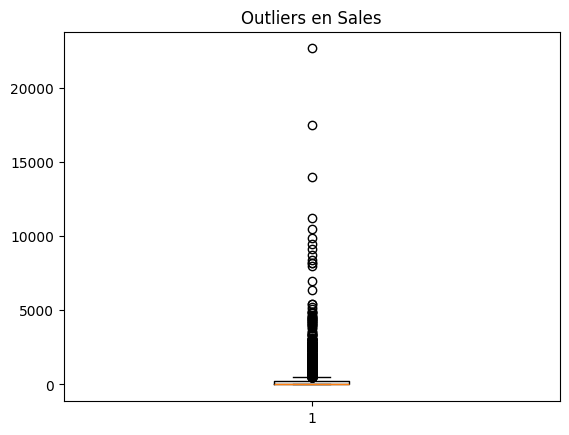

In [ ]:
plt.boxplot(data__train["Sales"])
plt.title("Outliers en Sales")
plt.show()

In [ ]:
# Calcular cuartiles
Q1 = data__train["Sales"].quantile(0.25)
Q3 = data__train["Sales"].quantile(0.75)

# Calcular IQR
IQR = Q3 - Q1

# Límites
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# Filtrar outliers
outliers = data__train[(data__train["Sales"] < lim_inf) | (data__train["Sales"] > lim_sup)]

# Cantidad de outliers
print("Cantidad de outliers:", len(outliers))

Cantidad de outliers: 1145


# VALIDACIÓN

In [ ]:
data__train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           9800 non-null   int64         
 1   Order ID         9800 non-null   object        
 2   Order Date       9800 non-null   datetime64[ns]
 3   Ship Date        9800 non-null   datetime64[ns]
 4   Ship Mode        9800 non-null   object        
 5   Customer ID      9800 non-null   object        
 6   Customer Name    9800 non-null   object        
 7   Segment          9800 non-null   object        
 8   Country          9800 non-null   object        
 9   City             9800 non-null   object        
 10  State            9800 non-null   object        
 11  Postal Code      9800 non-null   object        
 12  Region           9800 non-null   object        
 13  Product ID       9800 non-null   object        
 14  Category         9800 non-null   object 

### Verificación de Ausencia de Valores Nulos


In [ ]:
data__train.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
data__train.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month Name,Nivel_Ventas,Month_Name,Quarter,Region_Category,Shipping_Time
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,Alto,November,2017Q4,South - Furniture,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,Alto,November,2017Q4,South - Furniture,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,Bajo,June,2017Q2,West - Office Supplies,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,Alto,October,2016Q4,South - Furniture,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,Bajo,October,2016Q4,South - Office Supplies,7


##  Exportación del Dataset Limpio


In [ ]:
#EXPORTACIÓN DEL DATA SET LIMPIO

data__train.to_csv("train_clean.csv", index=False)